# MovieIQ — Predictive Analytics on Film Success

#

# Stage 0: Problem Statement

### 0.1 What makes a movie successful?

In this project, a movie is considered successful when the revenue it generates is greater than its budget.

The rule we will use to label each movie is:

success = 1 if revenue > budget
success = 0 otherwise

Here, 1 represents a successful movie and 0 represents a movie that is not successful.

###

### 0.2 Why is predicting film success valuable?

Predicting whether a movie is likely to succeed can help people make better decisions before and during a movie's release.

**Movie studios**:
Studios can use predictions to understand the possible financial outcome of a movie. This can help them make decisions about budgets, production, and marketing.

**Investors**:
Investors can use the prediction to assess the possible financial performance of a movie before putting money into it. This may help them make better investment decisions.

##

### 0.3 Objective of the project

The main objective of MovieIQ is to analyze movie data and build a machine learning model that can predict whether a movie will be financially successful.

To achieve this, I will:

- Clean and prepare the movie dataset.
- Explore the relationships between movie features such as budget, revenue, popularity, runtime, and vote average.
- Perform statistical tests to check whether some features are significantly related to movie success.
- Train a Random Forest classification model to predict movie success.
- Evaluate the model using accuracy, precision, recall, and a confusion matrix.
- Build a Streamlit dashboard where users can explore the analysis and make predictions for a movie.

## 

### 0.4 Why is this a classification problem?

This project is a classification problem because the model has to place each movie into one of two categories:

1 → Successful
0 → Not successful

The model is not trying to predict an exact revenue amount. Instead, it is trying to predict which category a movie belongs to.

**The target variable of the model will therefore be: success**

It will be created using the movie's budget and revenue:
success = 1  # revenue > budget
success = 0  # revenue <= budget

##

#

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


## Stage 1: Data Preparation

####

### Task 1.1: Load the Dataset

In [2]:
df = pd.read_csv(r"C:\Users\Dcost\anaconda_projects\69c8cac9-9072-4b46-8e2a-bef526793eaa\MOVIE_IQ\movies.csv")
df.head()

,budget,revenue,popularity,runtime,vote_average,title,genres
0,57755036,107323371,60.377360,98,6.611888,Movie 1,"[{'id': 10749, 'name': 'Romance'}]"
1,192100010,342896533,86.289857,96,7.184687,Movie 2,"[{'id': 18, 'name': 'Drama'}]"
2,128521863,253206827,86.995324,148,3.542978,Movie 3,"[{'id': 35, 'name': 'Comedy'}]"
3,156299516,89635602,72.710096,118,5.985176,Movie 4,"[{'id': 18, 'name': 'Drama'}]"
4,148532820,221133868,74.829585,161,4.578480,Movie 5,"[{'id': 35, 'name': 'Comedy'}]"


In [3]:
print(df[df['title'] == "Movie 99"])

      budget    revenue  popularity  runtime  vote_average     title  \
98  52757120  155452980   94.053247      155      3.857075  Movie 99   

                                      genres  
98  [{'id': 878, 'name': 'Science Fiction'}]  


In [4]:
print(df.shape)

(2000, 7)


####

In [5]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   budget        2000 non-null   int64  
 1   revenue       2000 non-null   int64  
 2   popularity    2000 non-null   float64
 3   runtime       2000 non-null   int64  
 4   vote_average  2000 non-null   float64
 5   title         2000 non-null   object 
 6   genres        2000 non-null   object 
dtypes: float64(2), int64(3), object(2)
memory usage: 109.5+ KB
None


####

In [6]:
print(df.describe())

             budget       revenue   popularity      runtime  vote_average
count  2.000000e+03  2.000000e+03  2000.000000  2000.000000   2000.000000
mean   1.019211e+08  1.780574e+08    50.090738   129.568000      6.036764
std    5.682795e+07  1.293879e+08    28.482104    28.906507      1.743093
min    1.070640e+06  1.138729e+06     1.018466    80.000000      3.008133
25%    5.274832e+07  7.458306e+07    25.720784   104.000000      4.583298
50%    1.026023e+08  1.484882e+08    50.210396   130.000000      6.052901
75%    1.507962e+08  2.623679e+08    74.925354   155.000000      7.577305
max    1.999879e+08  5.744901e+08    99.764659   179.000000      8.998509


####

In [7]:
print(f"Total number of rows: {df.shape[0]}")
print(f"Total number of columns: {df.shape[1]}")

Total number of rows: 2000
Total number of columns: 7


##

### Task 1.2: Check Missing Values and Zeros

In [8]:
df.isnull().sum()

budget          0
revenue         0
popularity      0
runtime         0
vote_average    0
title           0
genres          0
dtype: int64

In [9]:
zero_budget = (df['budget'] == 0).sum()
zero_revenue = (df['revenue'] == 1).sum()

print(f"No. of Rows with budget = 0: {zero_budget}")
print(f"No. of Rows with revenue = 0: {zero_revenue}")

No. of Rows with budget = 0: 0
No. of Rows with revenue = 0: 0


#### Why are zero values a problem?

A budget or revenue of 0 may not mean that the movie actually had no budget or made no money. It can represent missing or unavailable information.

This is important because our definition of success depends directly on budget and revenue. If these values are incorrect, our success labels could also be incorrect.

#

### Task 1.3: Create the Target Variable

In [10]:
# Create the target variable
# 1 = Successful movie
# 0 = Unsuccessful movie

df["success"] = np.where(df["revenue"] > df["budget"], 1, 0)

# Display the first few rows
print(df[["budget", "revenue", "success"]].head())


# Count successful and unsuccessful movies
success_counts = df["success"].value_counts()
print("\nUnsuccessful movies:", success_counts.get(0, 0))
print("Successful movies:", success_counts.get(1, 0))


# Calculate the percentage of each class
success_percentage = df["success"].value_counts(normalize=True) * 100

print("\n",success_percentage)

      budget    revenue  success
0   57755036  107323371        1
1  192100010  342896533        1
2  128521863  253206827        1
3  156299516   89635602        0
4  148532820  221133868        1

Unsuccessful movies: 386
Successful movies: 1614

 success
1    80.7
0    19.3
Name: proportion, dtype: float64


####

### Success Distribution

After creating the `success` variable, 80.7% of the movies are classified as successful, while 19.3% are classified as unsuccessful.

This shows that the target variable is imbalanced because successful movies are much more common than unsuccessful movies. We should keep this in mind when evaluating our classification model later, since accuracy alone may not give us the full picture.

##

In [11]:
print(df['genres'].head().dtype)

object


In [12]:
print(df['genres'].head())

0    [{'id': 10749, 'name': 'Romance'}]
1         [{'id': 18, 'name': 'Drama'}]
2        [{'id': 35, 'name': 'Comedy'}]
3         [{'id': 18, 'name': 'Drama'}]
4        [{'id': 35, 'name': 'Comedy'}]
Name: genres, dtype: object


In [23]:
import ast

def process_genres(x):

    # Handle missing values
    if x is None or (isinstance(x, float) and pd.isna(x)):
        return ["Unknown"]

    # If the value is a string
    if isinstance(x, str):

        # Try to convert a string representation of a list into a Python object
        try:
            x = ast.literal_eval(x)
        except (ValueError, SyntaxError):
            # If it is already a genre name such as "Drama"
            return [x]

    # If the value is a list
    if isinstance(x, list):

        genres = []

        for genre in x:

            # If the list contains dictionaries
            if isinstance(genre, dict):
                genres.append(genre["name"])

            # If the list already contains genre names
            elif isinstance(genre, str):
                genres.append(genre)

        return genres if genres else ["Unknown"]

    # Handle any unexpected value
    return ["Unknown"]


# Apply the function to the genres column
df["genres"] = df["genres"].apply(process_genres)

# Check the result
df["genres"].head()


0    [Romance]
1      [Drama]
2     [Comedy]
3      [Drama]
4     [Comedy]
Name: genres, dtype: object

### Processing the Genres Column

The `genres` column is stored as a string representation of a list of dictionaries. I converted these strings into Python lists using `ast.literal_eval()` and extracted only the genre names. This makes the column easier to use for genre analysis and filtering.

#

## Stage 2: Exploratory Data Analysis

####

#### Task 2.1: Budget vs Revenue

In [ ]:
# Create a scatter plot to examine the relationship between budget and revenue
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=df,
    x="budget",
    y="revenue"
)

plt.title("Budget vs Revenue")
plt.xlabel("Budget")
plt.ylabel("Revenue")

plt.show()

#### Insight from Scatter plot - Budget v/s Revenue
The scatter plot shows a positive relationship between movie budget and revenue. In general, movies with higher budgets tend to earn higher revenues. However, the points are widely spread, especially for higher-budget movies, which shows that budget alone does not guarantee high revenue.

#

### Step 2.2.1 — Find the most common genres

In [ ]:
from collections import Counter

# Combine all genre lists into one list
all_genres = []

for genre_list in df["genres"]:
    all_genres.extend(genre_list)


# Count how many movies belong to each genre
genre_counts = Counter(all_genres)

genre_counts_df = pd.DataFrame(
    genre_counts.items(),
    columns=["Genre", "Movie_Count"]
)

genre_counts_df

genre_counts_df_sorted = genre_counts_df.sort_values(
    by="Movie_Count",
    ascending=False
)
print(genre_counts_df_sorted)

In [ ]:
# Create a bar chart showing the number of movies in each genre
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_counts_df,
    x="Genre",
    y="Movie_Count"
)

# Add title and axis labels
plt.title("Number of Movies by Genre")
plt.xlabel("Genre")
plt.ylabel("Number of Movies")

# Rotate genre names for better readability
plt.xticks(rotation=45)

plt.show()

#### Most common movie genres

Romance is the most common genre in the dataset, with 220 movies, followed by Adventure, Science Fiction, and Animation. Action is the least common, with 192 movies. Overall, the number of movies across the different genres is fairly similar, so there is no single genre that strongly dominates the dataset.

#### 

### Step 2.2.3 — Calculate success rate by genre

In [ ]:
# Create an empty list to store genre-level results
genre_success = []

# Calculate success rate for each genre
for genre in genre_counts_df["Genre"]:
    
    # Select movies that belong to the current genre
    genre_movies = df[df["genres"].apply(lambda x: genre in x)]
    
    # Calculate the percentage of successful movies
    success_rate = genre_movies["success"].mean() * 100
    
    # Store the genre and its success rate
    genre_success.append([genre, success_rate])

# Convert the results into a DataFrame
genre_success_df = pd.DataFrame(
    genre_success,
    columns=["Genre", "Success Rate"]
)

# Sort genres from highest to lowest success rate
genre_success_df = genre_success_df.sort_values(
    by="Success Rate",
    ascending=False
)

# Display the results
genre_success_df

In [ ]:
# Create a bar chart showing the success rate of each genre
plt.figure(figsize=(10, 6))

sns.barplot(
    data=genre_success_df,
    x="Genre",
    y="Success Rate"
)

# Add title and axis labels
plt.title("Movie Success Rate by Genre")
plt.xlabel("Genre")
plt.ylabel("Success Rate (%)")

# Rotate genre names for better readability
plt.xticks(rotation=45)

plt.show()

####

#### Success rate by genre
Drama has the highest success rate at 82.23%, followed by Horror at 81.91% and Animation at 81.28%. Science Fiction has the lowest success rate at 78.54%, followed by Action at 78.65%. However, the success rates across all genres are fairly close, ranging from about 78.5% to 82.2%. This suggests that there are differences between genres, but the differences are not very large.

#
#

### TASK 2.3.1: Popularity vs Success

In [ ]:
# Compare popularity between successful and unsuccessful movies

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="success",
    y="popularity"
)

plt.title("Popularity vs Movie Success")
plt.xlabel("Success (0 = Unsuccessful, 1 = Successful)")
plt.ylabel("Popularity")

plt.show()

#### Successful movies tend to have slightly higher popularity than unsuccessful movies. However, the difference is not very large, and there is considerable overlap between the two groups.

##

### TASK 2.3.2: Runtime vs Success

In [ ]:
# Compare runtime between successful and unsuccessful movies

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="success",
    y="runtime"
)

plt.title("Runtime vs Movie Success")
plt.xlabel("Success (0 = Unsuccessful, 1 = Successful)")
plt.ylabel("Runtime (minutes)")

plt.show()

#### Runtime does not appear to have a strong relationship with movie success. Successful and unsuccessful movies have very similar runtime distributions, with their median runtimes being almost the same.

### TASK 2.3.3: Vote Average vs Success

In [ ]:
# Compare vote average between successful and unsuccessful movies

plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="success",
    y="vote_average"
)

plt.title("Vote Average vs Movie Success")
plt.xlabel("Success (0 = Unsuccessful, 1 = Successful)")
plt.ylabel("Average Vote")

plt.show()

### The boxplot shows that the vote average distributions for successful and unsuccessful movies are very similar. Both groups have a median vote average of around 6, with considerable overlap between their distributions. Successful movies do not appear to have noticeably higher vote averages than unsuccessful movies. Therefore, based on this plot alone, vote average does not show a strong relationship with movie success.

#

### TASK 2.4: Correlation heatmap for numerical features

In [ ]:
df_copy = df.drop(columns=['title', 'genres'])
corr = df_copy.corr()
plt.figure(figsize= (6, 5))
sns.heatmap(corr, annot=True)
plt.rc("ytick", labelsize=2)
plt.show()

## Correlation between features

**1. Budget and revenue**

The strongest correlation in the heatmap is between budget and revenue (0.76).

This indicates a strong positive relationship: movies with larger budgets generally tend to have higher revenues. This agrees with what we observed earlier in the Budget vs Revenue scatter plot.

**2. Revenue and success**

Revenue has a correlation of 0.37 with success, which is a moderate positive correlation.

However, this needs to be interpreted carefully. Our success variable was created using:

success = 1 if revenue > budget

Therefore, revenue and success are naturally related. This is not an independent finding and is important when building the model.

**3. Other variables**

The correlations between success and the other variables are very close to zero:

Popularity: 0.046
Runtime: -0.035
Vote average: -0.023




#
#

## Stage 3: Statistical Testing 

#### Task 3.1: T-Test

In [24]:
# Import the t-test function from scipy
from scipy.stats import ttest_ind

# Separate popularity values based on movie success
successful_popularity = df[df["success"] == 1]["popularity"]
unsuccessful_popularity = df[df["success"] == 0]["popularity"]

# Perform an independent two-sample t-test
# equal_var=False is used because the two groups may have different variances
t_stat, p_value = ttest_ind(
    successful_popularity,
    unsuccessful_popularity,
    equal_var=False
)

# Display the results
print("T-statistic:", t_stat)
print("P-value:", p_value)

# Set the significance level
alpha = 0.05

# Make the statistical decision
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant difference in popularity between successful and unsuccessful movies.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant difference in popularity between successful and unsuccessful movies.")

T-statistic: 2.0616702513558818
P-value: 0.03968244490792032
Reject the null hypothesis.
There is a statistically significant difference in popularity between successful and unsuccessful movies.


##

#### Task 3.2: Chi-Square Test

In [25]:
# Create a separate row for each genre of a movie
genre_df = df.explode("genres")

# Display the first few rows
genre_df[["title", "genres", "success"]].head()

# Create a contingency table showing genre against movie success
genre_success_table = pd.crosstab(
    genre_df["genres"],
    genre_df["success"]
)

# Rename the columns for easier understanding
genre_success_table.columns = ["Unsuccessful", "Successful"]

# Display the table
genre_success_table


,Unsuccessful,Successful
genres,,
Action,41,151
Adventure,41,166
Animation,38,165
Comedy,38,164
Drama,35,162
Horror,36,163
Romance,42,178
Science Fiction,44,161
Thriller,37,157


In [26]:
# Import the chi-square test function
from scipy.stats import chi2_contingency

# Perform the Chi-Square test
chi2_stat, p_value, degrees_freedom, expected = chi2_contingency(
    genre_success_table
)

# Display the results
print("Chi-Square statistic:", chi2_stat)
print("Degrees of freedom:", degrees_freedom)
print("P-value:", p_value)

# Set the significance level
alpha = 0.05

# Make the statistical decision
if p_value < alpha:
    print("Reject the null hypothesis.")
    print("There is a statistically significant association between genre and movie success.")
else:
    print("Fail to reject the null hypothesis.")
    print("There is no statistically significant association between genre and movie success.")

Chi-Square statistic: 1.7730811979406715
Degrees of freedom: 9
P-value: 0.9945690204257113
Fail to reject the null hypothesis.
There is no statistically significant association between genre and movie success.


### Understanding the P-Value

A p-value helps us decide whether the result of a statistical test provides enough evidence against the null hypothesis.

In this project, I use 0.05 as the significance level.

If the p-value is less than 0.05, I reject the null hypothesis and consider the result statistically significant.

If the p-value is greater than or equal to 0.05, I fail to reject the null hypothesis because there is not enough statistical evidence to support a difference or association.

The 0.05 threshold is commonly used as a practical cutoff for statistical significance. However, a statistically significant result does not necessarily mean that the relationship is large or important in practical terms.

#
#

Stage 4.1 — Select Features and Target

The question asks:

Which columns did you feed the model, and why did you exclude any (e.g. title, or revenue itself)?

Based on your dataset and the work we've done, I recommend using these four features:

budget
popularity
runtime
vote_average
Why these features?

They are numeric movie characteristics that can potentially help the model identify patterns related to success.

Why exclude the other columns?
revenue → Excluded because success was directly created using revenue. Including it would cause data leakage.
title → Excluded because each movie has a unique title and it does not provide a useful numerical feature for this project.
genres → Excluded from the initial Random Forest model because it is a list of categorical values and would need additional encoding. The project can still use genres for EDA and filtering in the dashboard.

In [27]:
# ============================================
# Stage 4.1 — Feature and Target Selection
# ============================================

# Select the numerical features for the model
X = df[
    [
        "budget",
        "popularity",
        "runtime",
        "vote_average"
    ]
]

# Select the target variable
y = df["success"]

# Display the selected features and target
print("Features used for modelling:")
print(X.columns.tolist())

print("\nTarget variable:")
print(y.name)

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features used for modelling:
['budget', 'popularity', 'runtime', 'vote_average']

Target variable:
success

Feature shape: (2000, 4)
Target shape: (2000,)


In [28]:
# ============================================
# Stage 4.2 — Train/Test Split
# ============================================

from sklearn.model_selection import train_test_split

# Split the data into 80% training and 20% testing
# stratify=y keeps the success/unsuccessful proportions similar
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# Display the sizes of each dataset
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

# Check the target distribution in each set
print("\nTraining target distribution:")
print(y_train.value_counts(normalize=True) * 100)

print("\nTest target distribution:")
print(y_test.value_counts(normalize=True) * 100)

Training set: (1600, 4)
Test set: (400, 4)

Training target distribution:
success
1    80.6875
0    19.3125
Name: proportion, dtype: float64

Test target distribution:
success
1    80.75
0    19.25
Name: proportion, dtype: float64


In [29]:
# ============================================
# Stage 4.3 — Train Random Forest Classifier
# ============================================

from sklearn.ensemble import RandomForestClassifier

# Create the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

# Train the model using the training data
rf_model.fit(X_train, y_train)

print("Random Forest model trained successfully.")

Random Forest model trained successfully.


Model Evaluation
----------------------------------------
Accuracy  : 0.8025
Precision : 0.8065
Recall    : 0.9938

Confusion Matrix:
[[  0  77]
 [  2 321]]


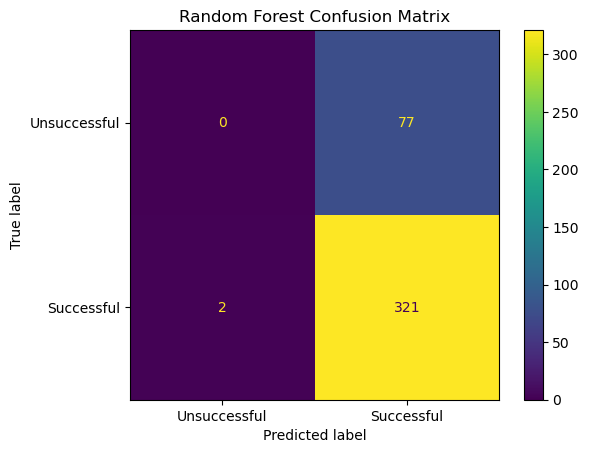

In [30]:
# ============================================
# Stage 4.4 — Model Evaluation
# ============================================

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

# Make predictions on the test data
y_pred = rf_model.predict(X_test)

# Calculate evaluation metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)

# Display the metrics
print("Model Evaluation")
print("----------------------------------------")
print(f"Accuracy  : {accuracy:.4f}")
print(f"Precision : {precision:.4f}")
print(f"Recall    : {recall:.4f}")

# Display the confusion matrix values
cm = confusion_matrix(y_test, y_pred)

print("\nConfusion Matrix:")
print(cm)

# Display the confusion matrix as a plot
ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Unsuccessful", "Successful"]
).plot()

plt.title("Random Forest Confusion Matrix")
plt.show()

In [32]:
# ============================================
# Stage 4.5 — Feature Importance
# ============================================

# Get feature importance values from the trained Random Forest
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

# Sort features from most important to least important
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

# Display the feature importance values
print(feature_importance)

        Feature  Importance
0        budget    0.263129
1    popularity    0.263105
3  vote_average    0.262046
2       runtime    0.211720


### Features that matter most for predicting success

- Budget, popularity, and vote average have almost identical importance. Their values are all around 0.26, so the Random Forest did not identify one of these three as clearly more important than the others.

## Does this agree with the EDA?

- The results only partly agree with the EDA. The EDA showed very weak correlations between the selected features and success, while the Random Forest identified some of these features as useful for making predictions. This difference may be because Random Forest can capture non-linear relationships that are not reflected by simple correlation values. Overall, no single feature clearly dominates the model.

####

## Final summarry of Random forest model:

The Random Forest achieved an accuracy of 80.25%, precision of 80.65%, and recall of 99.38%. The high recall shows that the model correctly identifies almost all successful movies. However, the confusion matrix shows that none of the unsuccessful movies were correctly classified, while 77 unsuccessful movies were incorrectly predicted as successful. Therefore, although the accuracy appears reasonable, the model has difficulty identifying unsuccessful movies. This is likely related to the imbalance in the target variable, where successful movies make up 80.7% of the dataset. Therefore, accuracy alone does not provide a complete picture of the model's performance.